<a href="https://colab.research.google.com/github/LuisMesa10/DeepLearning/blob/main/RETO_2_LANDUSE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# =========================
# IMPORTS
# =========================

# Librerías para manejo de datos e imágenes
import numpy as np
import cv2
import os

# Librerías para visualización de resultados
import matplotlib.pyplot as plt
import seaborn as sns

# Modelo preentrenado y herramientas de deep learning
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.optimizers import Adam

# Herramientas para preparar y evaluar los datos
from sklearn.preprocessing import LabelBinarizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# Conexión a Google Drive para acceder al dataset
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
# =========================
# RUTA Y CLASES
# =========================

# Ruta donde está el dataset en Drive
base_path = '/content/drive/MyDrive/Reto 4 Vision/landuse/'

# Clases que se van a usar para la clasificación
subfolders = ['buildings', 'airplane', 'river']

# Listas para guardar imágenes y sus etiquetas
data = []
labels = []

# =========================
# CARGA DE IMÁGENES
# =========================

# Recorrer cada clase
for subfolder in subfolders:
    print('Cargando:', subfolder)

    # Construir la ruta de cada carpeta
    path = os.path.join(base_path, subfolder)

    # Obtener solo las imágenes .png
    files = [f for f in os.listdir(path) if f.endswith('.png')]

    # Leer cada imagen
    for file in files:
        img = cv2.imread(os.path.join(path, file))  # Cargar imagen
        img = cv2.resize(img, (224,224))            # Redimensionar
        img = img.astype('float32') / 255.0         # Normalizar

        data.append(img)        # Guardar imagen
        labels.append(subfolder)  # Guardar etiqueta

# Convertir listas a arreglos de numpy
data = np.array(data)
labels = np.array(labels)

Cargando: buildings
Cargando: airplane
Cargando: river


In [ ]:
# =========================
# PREPROCESAMIENTO
# =========================

# Convertir las etiquetas de texto a formato numérico
lb = LabelBinarizer()
labels = lb.fit_transform(labels)

# Dividir los datos en entrenamiento (75%) y prueba (25%)
(trainX, testX, trainY, testY) = train_test_split(
    data, labels, test_size=0.25, random_state=42
)

In [ ]:
# =========================
# MODELO RESNET (TRANSFER LEARNING)
# =========================

# Cargar modelo ResNet50 preentrenado (sin la parte final)
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

# Congelar la mayoría de capas y dejar algunas para entrenamiento (fine-tuning)
for layer in base_model.layers[:-30]:
    layer.trainable = False

for layer in base_model.layers[-30:]:
    layer.trainable = True

# Agregar capas propias para la clasificación
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(3, activation='softmax')(x)

# Definir el modelo final
model = Model(inputs=base_model.input, outputs=output)

# Mostrar la estructura del modelo
model.summary()

# Compilar el modelo
model.compile(
    loss='categorical_crossentropy',
    optimizer=Adam(learning_rate=1e-5),
    metrics=['accuracy']
)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 23,850,371 (90.98 MB)

 Trainable params: 14,712,835 (56.13 MB)

 Non-trainable params: 9,137,536 (34.86 MB)

In [ ]:
# =========================
# ENTRENAMIENTO
# =========================

# Generador de imágenes para aplicar aumentos (data augmentation)
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=20,      # Rotación de imágenes
    zoom_range=0.2,         # Zoom
    horizontal_flip=True,   # Volteo horizontal
    shear_range=0.1         # Deformación ligera
)

# Ajustar el generador a los datos de entrenamiento
datagen.fit(trainX)

# Entrenar el modelo usando imágenes aumentadas
H = model.fit(
    datagen.flow(trainX, trainY, batch_size=32),
    validation_data=(testX, testY),
    epochs=15
)

Epoch 1/15
36/36 ━━━━━━━━━━━━━━━━━━━━ 58s 873ms/step - accuracy: 0.5733 - loss: 0.9020 - val_accuracy: 0.2320 - val_loss: 1.1267
Epoch 2/15
36/36 ━━━━━━━━━━━━━━━━━━━━ 15s 418ms/step - accuracy: 0.7084 - loss: 0.6785 - val_accuracy: 0.3067 - val_loss: 1.0924
Epoch 3/15
36/36 ━━━━━━━━━━━━━━━━━━━━ 15s 419ms/step - accuracy: 0.7467 - loss: 0.6202 - val_accuracy: 0.3760 - val_loss: 1.0776
Epoch 4/15
36/36 ━━━━━━━━━━━━━━━━━━━━ 15s 413ms/step - accuracy: 0.7609 - loss: 0.5859 - val_accuracy: 0.4640 - val_loss: 1.0218
Epoch 5/15
36/36 ━━━━━━━━━━━━━━━━━━━━ 15s 417ms/step - accuracy: 0.7964 - loss: 0.5250 - val_accuracy: 0.5707 - val_loss: 0.8852
Epoch 6/15
36/36 ━━━━━━━━━━━━━━━━━━━━ 15s 415ms/step - accuracy: 0.8098 - loss: 0.5043 - val_accuracy: 0.5547 - val_loss: 0.8319
Epoch 7/15
36/36 ━━━━━━━━━━━━━━━━━━━━ 15s 414ms/step - accuracy: 0.8053 - loss: 0.4734 - val_accuracy: 0.7200 - val_loss: 0.7052
Epoch 8/15
36/36 ━━━━━━━━━━━━━━━━━━━━ 15s 414ms/step - accuracy: 0.8302 - loss: 0.4391 - val_accu

In [ ]:
# =========================
# EVALUACIÓN
# =========================

# Realizar predicciones sobre los datos de prueba
predictions = model.predict(testX)

# Mostrar el reporte de clasificación (precision, recall, f1-score)
print("\n===== REPORTE DE CLASIFICACIÓN =====")
print(classification_report(
    testY.argmax(axis=1),          # Clases reales
    predictions.argmax(axis=1),    # Clases predichas
    target_names=lb.classes_       # Nombres de las clases
))

12/12 ━━━━━━━━━━━━━━━━━━━━ 9s 526ms/step

===== REPORTE DE CLASIFICACIÓN =====
              precision    recall  f1-score   support

    airplane       0.84      0.90      0.87       115
   buildings       0.86      0.87      0.87       125
       river       0.94      0.88      0.91       135

    accuracy                           0.88       375
   macro avg       0.88      0.88      0.88       375
weighted avg       0.88      0.88      0.88       375



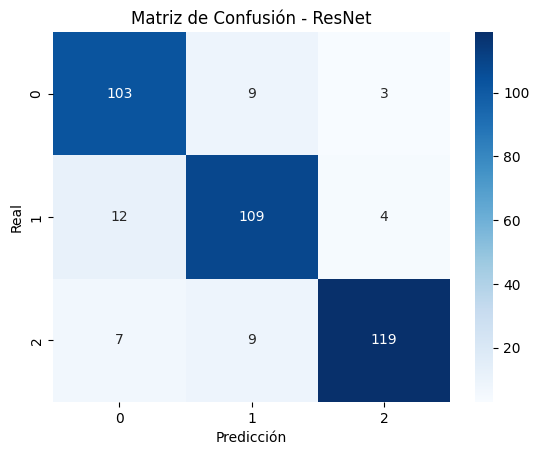

In [ ]:
# =========================
# MATRIZ DE CONFUSIÓN
# =========================

# Calcular la matriz de confusión
cm = confusion_matrix(
    testY.argmax(axis=1),        # Clases reales
    predictions.argmax(axis=1)   # Clases predichas
)

# Visualizar la matriz de confusión
plt.figure()
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')  # Mostrar valores en la matriz
plt.title("Matriz de Confusión - ResNet")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()

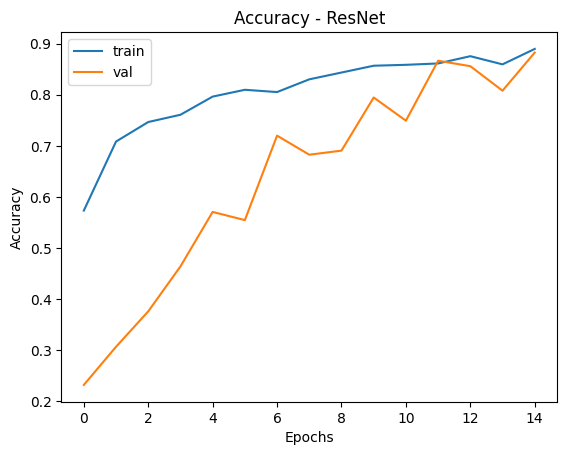

In [ ]:
# =========================
# GRÁFICA DE ENTRENAMIENTO
# =========================

# Crear gráfica del accuracy durante el entrenamiento
plt.figure()
plt.plot(H.history['accuracy'], label='train')       # Accuracy en entrenamiento
plt.plot(H.history['val_accuracy'], label='val')     # Accuracy en validación

# Configuración de la gráfica
plt.title("Accuracy - ResNet")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

# Mostrar gráfica
plt.show()

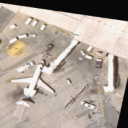

Ground truth class:  airplane
Predicted class:  airplane


In [ ]:
# Mostrar una imagen aleatoria y su predicción

from google.colab.patches import cv2_imshow
import random

# Seleccionar una posición aleatoria del conjunto de prueba
rand_pos = random.randint(0, len(testX))

# Obtener la imagen correspondiente
rand_img = testX[rand_pos]

# Ajustar la imagen para visualizarla correctamente
rand_img_resized = 255 * cv2.resize(rand_img, (128, 128))

# Mostrar la imagen
cv2_imshow(rand_img_resized)

# Mostrar la clase real y la predicha por el modelo
print('Ground truth class: ', lb.classes_[np.argmax(testY[rand_pos])])
print('Predicted class: ', lb.classes_[np.argmax(predictions[rand_pos])])